In [33]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import rcParams
from scipy.stats import ttest_ind,ttest_rel,zscore
from scipy.ndimage import gaussian_filter1d
import scipy.io as spio


params = {
        "font.family" : "Arial",
        'pdf.fonttype' : 42,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'axes.linewidth': 0.5,
        'xtick.labelsize':9,
        'xtick.major.width':0.5,
        'ytick.major.width':0.5,
        'ytick.labelsize':9,
        'axes.spines.top':False,
        'axes.spines.right':False
         }
rcParams['figure.figsize'] = 21.7,8.27
rcParams.update(params)

def format_ax(ax,xlim,ylim,xspace,yspace):
   

    ax.set_xticks(np.arange(xlim[0],xlim[1]+ xspace,xspace))
    ax.set_yticks(np.arange(ylim[0],ylim[1]+ yspace,yspace))

    ax.set(ylim=(ylim[0], ylim[1]))
    ax.set(xlim=(xlim[0], xlim[1]))


In [2]:
### Function to align trials to event onsets, adapted from https://www.tdt.com/docs/sdk/offline-data-analysis/offline-data-python/examples/LickBouts/#time-filter-around-lick-bout-epocs
def trial_align(event_on,time,values,fps = 20,pre = 2, post = 10):
    TRANGE = [-pre*np.floor(fps), post*np.floor(fps)]

    trial_snips = []
    array_ind = []
    pre_stim = []
    post_stim = []

    for on in event_on:
        
            # If the bout cannot include pre-time seconds before event, make zero
        if on < pre:
            pass

        else: 
            # find first time index after bout onset
            array_ind.append(np.where(time > on)[0][0])
            # find index corresponding to pre and post stim durations
            pre_stim.append(array_ind[-1] + TRANGE[0])
            post_stim.append(array_ind[-1] + TRANGE[1])
            trial_snips.append(values[int(pre_stim[-1]):int(post_stim[-1])])
    
    # If some snippets are less than max length, add nans to end of array

    max1 = np.max([np.size(x) for x in trial_snips])
    for i,x in enumerate(trial_snips):
        if np.size(x) < max1:
            trial_snips[i] = np.concatenate((trial_snips[i],np.full((max1-np.size(trial_snips[i])), np.nan)))
    
    mean_trial_snips = np.mean(trial_snips, axis=0)
    peri_time = np.linspace(1, len(mean_trial_snips), len(mean_trial_snips))/fps - pre
    return trial_snips,peri_time

In [3]:
### Function to get aligned dataframe for closed loop sessions.
def live_aligned_df(mouse_id,date,sess = "1",pre = 10,post = 10):

    path_start = fr"{base_dir}/{mouse_id}/{date}/"
    df = pd.read_csv(fr"{path_start}{mouse_id}_{date}_{sess}_areas.csv", names=["Area","Time"])
    dilation_df = pd.read_csv(fr"{path_start}{mouse_id}_{date}_{sess}_dilations.csv", names=["Times"])
    lasers = pd.read_csv(fr"{path_start}{mouse_id}_{date}_{sess}_laser.csv", names=["Times"])["Times"].tolist()
    nonlasers = pd.read_csv(fr"{path_start}{mouse_id}_{date}_{sess}_nonlasers.csv", names=["Times"])["Times"].tolist()

    dil_times = dilation_df["Times"].tolist()
    Area = df["Area"].tolist()
    Area =[x if x != 0 else np.nan for x in Area]
    Time = [i - df["Time"].tolist()[0] for i in df["Time"].tolist()]
    Dil_times = [i - df["Time"].tolist()[0] for i in dil_times]
    Lasers = [i - df["Time"].tolist()[0] for i in lasers]
    Nonlasers = [i - df["Time"].tolist()[0] for i in nonlasers]
    nan_removed_area = np.delete(Area, np.argwhere(np.isnan(Area)))
    nan_removed_times = np.delete(Time, np.argwhere(np.isnan(Area)))
    Time = np.arange(0,Time[-1],0.05)
    area = np.interp(Time, nan_removed_times, nan_removed_area)
    Area = zscore(area)
    Lasers = np.array(Lasers)
    Nonlasers = np.array(Nonlasers)
    Time = np.array(Time)
    Area = np.array(Area)
    laser_matrix,dil_times = trial_align(Lasers,Time,Area,fps = 20,pre = pre, post = post)
    df_list = []
    for j,trial in enumerate(laser_matrix):
        ##check if slope during trial is positive
        p = gaussian_filter1d(trial,20)
        p_deriv = np.gradient(p,dil_times)
        slope = np.mean(p_deriv[160:200])
        if slope >0:
            for i,time in enumerate(dil_times):
                new_dict = {"Time from Stim (s)" : np.round(time,2), "trial" : j, "Pupil Area" : trial[i],"Type":"Laser Trial","ID":mouse_id,"Date":date}
                df_list.append(new_dict)

    nonlaser_matrix,dil_times = trial_align(Nonlasers,Time,Area,fps = 20,pre = pre, post = post)
    for j,trial in enumerate(nonlaser_matrix):
        ##check if slope during trial is positive
        p = gaussian_filter1d(trial,20)
        p_deriv = np.gradient(p,dil_times)
        slope = np.mean(p_deriv[160:200])
        if slope >0:
            for i,time in enumerate(dil_times):
                new_dict = {"Time from Stim (s)" : np.round(time,2), "trial" : j, "Pupil Area" : trial[i],"Type":"Non-Laser Trial","ID":mouse_id,"Date":date}
                df_list.append(new_dict)
    aligned_df = pd.DataFrame.from_dict(df_list)
    return aligned_df


In [35]:
### Function to convert matlab struct to python dictionary, adapted from https://stackoverflow.com/questions/7008608/scipy-io-loadmat-nested-structures-i-e-dictionaries
def loadmat(filename):
    '''
    this function should be called instead of direct spio.loadmat
    as it cures the problem of not properly recovering python dictionaries
    from mat files. It calls the function check keys to cure all entries
    which are still mat-objects
    '''
    def _check_keys(d):
        '''
        checks if entries in dictionary are mat-objects. If yes
        todict is called to change them to nested dictionaries
        '''
        for key in d:
            if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
                d[key] = _todict(d[key])
        return d

    def _todict(matobj):
        '''
        A recursive function which constructs from matobjects nested dictionaries
        '''
        d = {}
        for strg in matobj._fieldnames:
            elem = matobj.__dict__[strg]
            if isinstance(elem, spio.matlab.mio5_params.mat_struct):
                d[strg] = _todict(elem)
            elif isinstance(elem, np.ndarray):
                d[strg] = _tolist(elem)
            else:
                d[strg] = elem
        return d

    def _tolist(ndarray):
        '''
        A recursive function which constructs lists from cellarrays
        (which are loaded as numpy ndarrays), recursing into the elements
        if they contain matobjects.
        '''
        elem_list = []
        for sub_elem in ndarray:
            if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):
                elem_list.append(_todict(sub_elem))
            elif isinstance(sub_elem, np.ndarray):
                elem_list.append(_tolist(sub_elem))
            else:
                elem_list.append(sub_elem)
        return elem_list
    data = spio.loadmat(filename, struct_as_record=False, squeeze_me=True)
    return _check_keys(data)

In [4]:
### Path to data. RENAME THIS TO YOUR PATH
base_dir = "/Users/nithik/Library/CloudStorage/Box-Box/SAS-DLS-HudaLab/Nithik-SciAdv2026-alldata"

In [ ]:
###cl
def area_at_detection(mouse_id,date,sess = "1",mac = True,smooth = False,pre = 10,post = 10):
    path_start = fr"{base_dir}/{mouse_id}/{date}/"
    df = pd.read_csv(fr"{path_start}{mouse_id}_{date}_{sess}_areas.csv", names=["Area","Time"])
    dilation_df = pd.read_csv(fr"{path_start}{mouse_id}_{date}_{sess}_dilations.csv", names=["Times"])
    lasers = pd.read_csv(fr"{path_start}{mouse_id}_{date}_{sess}_laser.csv", names=["Times"])["Times"].tolist()
    nonlasers = pd.read_csv(fr"{path_start}{mouse_id}_{date}_{sess}_nonlasers.csv", names=["Times"])["Times"].tolist()

    ### Get actual threshold for that session
    threshold_path = fr"{path_start}session_threshold.txt"
    with open(threshold_path, "r") as f:
        threshold = float(f.read().strip())

    dil_times = dilation_df["Times"].tolist()
    Area = df["Area"].tolist()
    Area =[x if x != 0 else np.nan for x in Area]
    if smooth:
        Area = np.convolve(Area, np.ones(15)/15, mode='same')

    Time = [i - df["Time"].tolist()[0] for i in df["Time"].tolist()]
    Dil_times = [i - df["Time"].tolist()[0] for i in dil_times]
    Lasers = [i - df["Time"].tolist()[0] for i in lasers]
    Nonlasers = [i - df["Time"].tolist()[0] for i in nonlasers]
    nan_removed_area = np.delete(Area, np.argwhere(np.isnan(Area)))
    nan_removed_times = np.delete(Time, np.argwhere(np.isnan(Area)))
    Time = np.arange(0,Time[-1],0.05)
    #Time = [np.round(x,2) for x in Time]
    area = np.interp(Time, nan_removed_times, nan_removed_area)
    Area = zscore(area)
    Time = np.array(Time)
    Area = np.array(Area)
    laser_matrix,dil_times = trial_align(Dil_times,Time,Area,fps = 20,pre = pre, post = post)
    pixel_matrix,pixel_times = trial_align(Dil_times,Time,area,fps = 20,pre = pre, post = post)

    df_list = []
    for j,trial in enumerate(laser_matrix):
        pixel_trial = pixel_matrix[j]
        pixel_at_detection = pixel_trial[200]
        new_dict = {"ID":mouse_id,"Date":date,"Pixel Area" : pixel_at_detection,"type": "Actual"}
        df_list.append(new_dict)
        new_dict = {"ID":mouse_id,"Date":date,"Pixel Area" : threshold,"type": "Expected"}
        df_list.append(new_dict)

    aligned_df = pd.DataFrame.from_dict(df_list)
    return aligned_df


In [31]:
### Get data for FigS3A

id_date = { 
"004072" : ["20230727","20230726"],
"004075" : ["20230727","20230726"],
"004109" : ["20230907","20230908"],
"004112" : ["20230908"],
"004110" : ["20230911"],
"004111" : ["20230911"],

"004253" : ["20240520"],
"004254" : ["20240521"],
"004255" : ["20240521"],
"004256" : ["20240521"],
"004257" : ["20240521"],
"004258" : ["20240521"],

"004259" : ["20240514"],
"004260" : ["20240514","20240517"],
"004261" : ["20240514"],
"004262" : ["20240514","20240522"],
"004263" : ["20240522"],
"004264" : ["20240514"],
 }


df_list = []
for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        df = area_at_detection(id,date,"1",mac = True,post = 15)
        df_list.append(df)
df = pd.concat(df_list)
thresh_df = df.reset_index()

004072 20230727
004072 20230726
004075 20230727
004075 20230726
004109 20230907
004109 20230908
004112 20230908
004110 20230911
004111 20230911
004253 20240520
004254 20240521
004255 20240521
004256 20240521
004257 20240521
004258 20240521
004259 20240514
004260 20240514
004260 20240517
004261 20240514
004262 20240514
004262 20240522
004263 20240522
004264 20240514


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/2948526964.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = thresh_df.groupby(["ID","type"]).mean().reset_index(), x = "type", y = "Pixel Area",errorbar = "se",fill = None,errwidth= 1,order = ["Expected","Actual"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/2948526964.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = thresh_df.groupby(["ID","type"]).mean().reset_index(), x = "type", y = "Pixel Area",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)


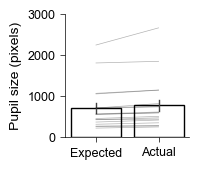

In [ ]:
### Plot FigS3A

plt.figure(figsize = (1.6,1.6))
g = sns.barplot(data = thresh_df.groupby(["ID","type"]).mean().reset_index(), x = "type", y = "Pixel Area",errorbar = "se",fill = None,errwidth= 1,order = ["Expected","Actual"])
sns.lineplot(data = thresh_df.groupby(["ID","type"]).mean().reset_index(), x = "type", y = "Pixel Area",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
for line in g.get_lines()[2:]:
    y1,y2 = line.get_ydata()
    line.set_ydata([y2,y1])

g.set_yticks(np.arange(0,5000,1000))
g.set(ylim=(0, 3000))
g.set_ylabel("Pupil size (pixels)")
g.xaxis.label.set_visible(False)

In [ ]:
### Get all closed-loop data for FigS3

id_date = { 
"004072" : ["20230727","20230726"],
"004075" : ["20230727","20230726"],
"004109" : ["20230907","20230908"],
"004112" : ["20230908"],
"004110" : ["20230911"],
"004111" : ["20230911"],

"004253" : ["20240520"],
"004254" : ["20240521"],
"004255" : ["20240521"],
"004256" : ["20240521"],
"004257" : ["20240521"],
"004258" : ["20240521"],

"004259" : ["20240514"],
"004260" : ["20240514","20240517"],
"004261" : ["20240514"],
"004262" : ["20240514","20240522"],
"004263" : ["20240522"],
"004264" : ["20240514"],
 }


df_list = []
for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        df = live_aligned_df(id,date,"1",post = 15)
        df_list.append(df)
df = pd.concat(df_list)
all_live_df = df.reset_index()

004072 20230727
004072 20230726
004075 20230727
004075 20230726
004109 20230907
004109 20230908
004112 20230908
004110 20230911
004111 20230911
004253 20240520
004254 20240521
004255 20240521
004256 20240521
004257 20240521
004258 20240521
004259 20240514
004260 20240514
004260 20240517
004261 20240514
004262 20240514
004262 20240522
004263 20240522
004264 20240514


In [ ]:
### Get data for FigS3B

bar_df_list = []
for ID in all_live_df.ID.unique():
    mouse_df = all_live_df.query(f"ID =='{ID}'")
    for type in mouse_df.Type.unique():
        type_df = mouse_df.query(f"Type =='{type}'")
        rslt_df = type_df.loc[type_df['Time from Stim (s)'] > 0]
        rslt_df = rslt_df.loc[rslt_df['Time from Stim (s)'] < 10]
        area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
        time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
        detection = area[0]
        new_dict = {"ID" : ID,"type": type,"Detection":detection}
        bar_df_list.append(new_dict)

all_df = pd.DataFrame.from_dict(bar_df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/3155476629.py:9: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/3155476629.py:10: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/3155476629.py:9: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprec

[Text(0, 0, 'Non\nlaser'), Text(1, 0, 'Laser')]

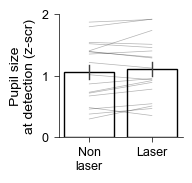

In [ ]:
### Plot FigS3B

plt.figure(figsize = (1.6,1.6))
g = sns.barplot(data = all_df, x = "type", y = "Detection",errorbar = "se",fill = None,errwidth= 1,order = ["Non-Laser Trial", "Laser Trial"])
sns.lineplot(data = all_df, x = "type", y = "Detection",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
for line in g.get_lines()[2:]:
    y1,y2 = line.get_ydata()
    line.set_ydata([y2,y1])

g.set_yticks(np.arange(0,3,1))
g.set(ylim=(0, 2))
g.set_ylabel("Pupil size\nat detection (z-scr)")
g.xaxis.label.set_visible(False)
labels = ["Non\nlaser","Laser"]
g.set_xticklabels(labels)

In [38]:
### Get data for FigS3C

id_date = { 
"004253": ["20240520"],
"004254": ["20240520"],
"004255": ["20240520"],
"004256": ["20240520"],
"004257": ["20240520"],
"004258": ["20240520"],
}
sess =1
pre = 10
post = 20
df_list = []
labels = list(range(1,5))
for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
        pupil_df = pd.read_csv(pupil_path)
        times = pupil_df["Time"].to_numpy()
        areas = pupil_df['Pupil Area'].to_numpy()
        mat_data = loadmat(matpath)["data"]
        laser_times = mat_data["response"]["laser_time"]
        pupil_snips,pupil_peri_times = trial_align(laser_times,times,areas,pre = pre, post = post)
        for j,trial in enumerate(pupil_snips):
            baseline = np.nanmean(trial[160:200])
            trial = trial - baseline
            for i,time in enumerate(pupil_peri_times):
                new_dict = {"Time from Laser (s)" : time, "trial" : j, "value" : trial[i],"type" : "pupil", "ID" : id, "date" : date,"sess":sess}
                df_list.append(new_dict)

v1_df = pd.DataFrame.from_dict(df_list)

004253 20240520


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004254 20240520


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004255 20240520


...

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004257 20240520


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004258 20240520


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


In [40]:
### Get data for FigS3D
id_date = { 
"004253": ["20240520"],
"004254": ["20240520"],
"004255": ["20240520"],
"004256": ["20240520"],
"004257": ["20240520"],
"004258": ["20240520"],
}

sess =1
pre = 10
post = 10
df_list = []
delta_list = []

for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
        pupil_df = pd.read_csv(pupil_path)
        times = pupil_df["Time"].to_numpy()
        areas = pupil_df['Pupil Area'].to_numpy()
        mat_data = loadmat(matpath)["data"]
        laser_times = mat_data["response"]["laser_time"]
        pupil_snips,pupil_peri_times = trial_align(laser_times,times,areas,pre = pre, post = post)

        for j,trial in enumerate(pupil_snips):
            pre_laser = np.nanmean(trial[160:200])
            post_laser = np.nanmean(trial[280:300])
            new_dict = {"Delta" : post_laser - pre_laser,"ID" : id,'Condition':"VGAT","Date":date,"trial":j}
            delta_list.append(new_dict)

delta_df = pd.DataFrame.from_dict(delta_list)

004253 20240520


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004254 20240520


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004255 20240520


...

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004257 20240520


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004258 20240520


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/3291146587.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = v1_df.groupby(["ID","type","Time from Laser (s)"]).mean().reset_index(), x = "Time from Laser (s)", y = "value",errorbar = "se",color = "dodgerblue",linewidth = 1)


Text(0, 0.5, 'Pupil size (z-scr)')

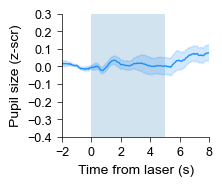

In [39]:
### Plot FigS3C

plt.figure(figsize = (1.9,1.6))
ax = sns.lineplot(data = v1_df.groupby(["ID","type","Time from Laser (s)"]).mean().reset_index(), x = "Time from Laser (s)", y = "value",errorbar = "se",color = "dodgerblue",linewidth = 1)
ax.axvspan(0,5,alpha = 0.2)
format_ax(ax,[-2,8],[-0.4,0.3],2,0.1)
ax.set_xlabel("Time from laser (s)")
ax.set_ylabel("Pupil size (z-scr)")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/3071750513.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = delta_df.groupby(["ID"]).mean().reset_index(), y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "dodgerblue")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_14958/3071750513.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.stripplot(data = delta_df.groupby(["ID"]).mean().reset_index(),y = "Delta",color = "black",alpha = 0.3,s = 3,jitter = 0.2)


Text(0.5, 0, 'V1')

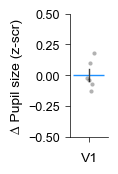

In [41]:
### Plot FigS3D

plt.figure(figsize = (0.5,1.6))
g = sns.barplot(data = delta_df.groupby(["ID"]).mean().reset_index(), y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "dodgerblue")
sns.stripplot(data = delta_df.groupby(["ID"]).mean().reset_index(),y = "Delta",color = "black",alpha = 0.3,s = 3,jitter = 0.2)
g.set_yticks(np.arange(-0.5,0.75,0.25))
g.set(ylim=(-0.5, 0.5))
g.set_ylabel("∆ Pupil size (z-scr)")
g.set_xlabel("V1")